In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from jaxpm import camels, data, plotting, graph
from jaxpm.painting import cic_paint, cic_read, cic_paint_2d

from jax import config
# config.update("jax_platform_name", "cpu")

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## plotting

In [3]:
def plot_preds(pred, label, pred_vali, label_vali):
    nrows = pred_vali.shape[0]
    ncols = 2
    
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))

    # fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))
    # ncols = y_true.shape[-1]

    for i in range(nrows):
        ax[i,0].scatter(label[i], pred[i], s=0.1, color="tab:blue")
    
        ax[i,0].plot([label[i].min(), label[i].max()], [label[i].min(), label[i].max()], color="k", linestyle="--")
        ax[i,0].set_aspect("equal")
        ax[i,0].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())

    ax[0,0].set(title="training")
    
    for i in range(nrows):
        ax[i,1].scatter(label_vali[i], pred_vali[i], s=0.1, color="tab:orange")
    
        ax[i,1].plot([label_vali[i].min(), label_vali[i].max()], [label_vali[i].min(), label_vali[i].max()], color="k", linestyle="--")
        ax[i,1].set_aspect("equal")
        ax[i,1].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())
    
    ax[0,1].set(title="validation")

    fig.tight_layout()

In [4]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)


def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
    
    residual = true_field_log_sum - pred_field_log_sum
    lim = np.max(np.abs(residual[np.isfinite(residual)]))
    print(lim)
    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

In [5]:
# parts_per_dim = 64
parts_per_dim = 128
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## CAMELS snapshots

In [6]:
i_snapshots = [-2, -1]
# i_snapshots = [0, -1]
# i_snapshots = range(1, 33+4, 4)
# i_snapshots = None
# i_snapshots = [-1]


In [7]:
train_dict = camels.load_CV_snapshots(
    "CV_1",
    # "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE="SIMBA",
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=128,mesh=128.h5


# Preprocessing

In [8]:
scales, particle_features, field_features = camels.preprocess_snapshots(train_dict)
# plotting.plot_gas_features(scales, field_features)

In [9]:
particle_features["gas_pos"].shape

(34, 2097152, 3)

In [10]:
gas_pos = particle_features["gas_pos"][-1]
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

In [11]:
gas_N.shape

(2097152,)

In [12]:
N_gas.shape

(128, 128, 128)

In [13]:
gas_pos.shape

(2097152, 3)

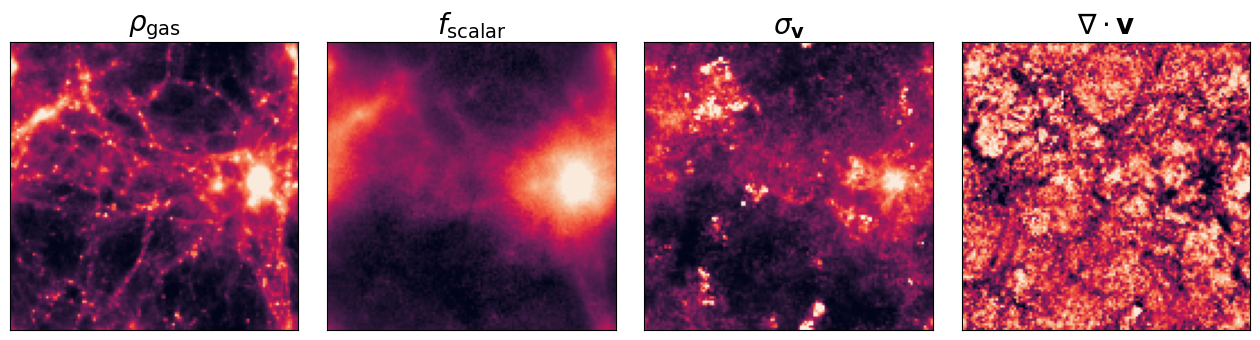

In [14]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

features = [
    "gas_rho",
    "gas_fscalar",
    "gas_vel_disp",
    "gas_vel_div",
]

feature_names = [
    r"$\rho_\text{gas}$",
    r"$f_\text{scalar}$",
    r"$\sigma_\mathbf{v}$",
    r"$\nabla \cdot \mathbf{v}$",
]

i = -1
ncols = len(features)
subplot_size = 4      # size of each square subplot
wspace = 0.1         # horizontal spacing between subplots
plot_mesh = 128

gas_pos = particle_features["gas_pos"][i]
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

cmap = sns.color_palette("rocket", as_cmap=True)

fig = plt.figure(figsize=(ncols*subplot_size, subplot_size))
gs = GridSpec(1, ncols, figure=fig, wspace=wspace)

empty_mesh = jnp.zeros((plot_mesh,) * 2)
for j, feature in enumerate(features):
    ax = fig.add_subplot(gs[0, j])
    weight = particle_features[feature][i] / gas_N
    field = cic_paint_2d(empty_mesh, gas_pos[:,[1,2]] * (plot_mesh // mesh_per_dim), weight)
    field = jnp.arcsinh(field / jnp.std(field))
    im = ax.imshow(field, cmap=cmap, vmin=jnp.percentile(field, 1), vmax=jnp.percentile(field, 99))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(feature_names[j], fontsize=20)

fig.savefig(f"plots/hpm_inputs_mesh={mesh_per_dim}.pdf", bbox_inches="tight", pad_inches=0, dpi=300)
# fig.savefig(f"plots/hpm_inputs_mesh={mesh_per_dim}.png", bbox_inches="tight", dpi=300)

In [15]:
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# import seaborn as sns

# features = [
#     "rho_gas",
#     "fscalar_gas",
#     "vel_disp_gas",
#     "vel_div_gas",
# ]

# feature_names = [
#     r"$\rho_\text{gas}$",
#     r"$f_\text{scalar}$",
#     r"$\sigma_\mathbf{v}$",
#     r"$\nabla \cdot \mathbf{v}$",
# ]

# i = -1
# ncols = len(features)
# subplot_size = 4      # size of each square subplot
# wspace = 0.1         # horizontal spacing between subplots

# cmap = sns.color_palette("rocket", as_cmap=True)

# fig = plt.figure(figsize=(ncols*subplot_size, subplot_size))
# gs = GridSpec(1, ncols, figure=fig, wspace=wspace)

# # empty_mesh = jnp.zeros((plot_mesh,) * 2)
# for j, feature in enumerate(features):
#     ax = fig.add_subplot(gs[0, j])
#     field = field_features[feature][i].sum(axis=0)
#     field = jnp.arcsinh(field / jnp.std(field))
#     im = ax.imshow(field, cmap=cmap)
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_title(feature_names[j], fontsize=20)

# fig.savefig(f"plots/hpm_inputs_mesh={mesh_per_dim}.pdf", bbox_inches="tight", dpi=300)

In [16]:
# features = [
#     "rho_gas",
#     "fscalar_gas",
#     "vel_disp_gas",
#     "vel_div_gas",
#     # "P_gas",
# ]

# feature_names = [
#     r"$\rho_\text{gas}$",
#     r"$f_\text{scalar}$",
#     r"$\sigma_\mathbf{v}$",
#     r"$\nabla \cdot \mathbf{v}$",
# ]

# i = -1
# ncols = len(features)
# cmap = sns.color_palette("rocket", as_cmap=True)
# # cmap = sns.color_palette("flare_r", as_cmap=True)
# # cmap = sns.color_palette("mako", as_cmap=True)
# # cmap = sns.color_palette("plasma", as_cmap=True)

# fig, ax = plt.subplots(ncols=ncols, figsize=(ncols * 2, 2))

# for j in range(ncols):
#     # shape (64, 64, 64)
#     field = field_features[features[j]][i]
#     field = field.sum(axis=0)
#     field = jnp.arcsinh(field/jnp.std(field))

#     im = ax[j].imshow(field, cmap=cmap)

#     ax[j].set_xticks([])
#     ax[j].set_yticks([])
#     ax[j].set(title=feature_names[j])

#     # fig.colorbar(im, ax=ax[j], orientation="horizontal", shrink=0.7, aspect=10, pad=0.02)

# fig.savefig("plots/hpm_inputs.pdf", bbox_inches="tight")

# trash

In [17]:
# features = [
#     "rho_gas",
#     "fscalar_gas",
#     "vel_disp_gas",
#     "vel_div_gas",
#     # "P_gas",
# ]

# feature_names = [
#     r"$\rho_\text{gas}$",
#     r"$f_\text{scalar}$",
#     r"$\sigma_\mathbf{v}$",
#     r"$\nabla \cdot \mathbf{v}$",
# ]

# i = -1
# ncols = len(features)
# cmap = sns.color_palette("rocket", as_cmap=True)
# # cmap = sns.color_palette("flare_r", as_cmap=True)
# # cmap = sns.color_palette("mako", as_cmap=True)
# # cmap = sns.color_palette("plasma", as_cmap=True)

# fig, ax = plt.subplots(ncols=ncols, figsize=(ncols * 2, 2))

# fields = jnp.stack([field_features[f][i] for f in features], axis=0)
# fields = fields.sum(axis=1)
# fields = jnp.arcsinh(fields/jnp.std(fields, axis=(1,2))[:,jnp.newaxis,jnp.newaxis])

# vmin = jnp.percentile(fields, 1)
# vmax = jnp.percentile(fields, 99)

# for j in range(ncols):
#     field = fields[j]
    
#     im = ax[j].imshow(field, cmap=cmap, vmin=vmin, vmax=vmax)

#     ax[j].set_xticks([])
#     ax[j].set_yticks([])
#     ax[j].set(title=feature_names[j])

#     fig.colorbar(im, ax=ax[j], orientation="horizontal", shrink=0.7, aspect=10, pad=0.02)



# # # fig.savefig("plots/hpm_inputs.pdf", bbox_inches="tight")